<a href="https://colab.research.google.com/github/BadhonPain/Machine_Learning/blob/ML/Dog_Cat_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset Preparation**

In [ ]:
!git clone https://github.com/laxmimerit/dog-cat-full-dataset.git

Cloning into 'dog-cat-full-dataset'...
remote: Enumerating objects: 25059, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 25059 (delta 4), reused 6 (delta 2), pack-reused 25048 (from 1)
Receiving objects: 100% (25059/25059), 541.54 MiB | 25.31 MiB/s, done.
Resolving deltas: 100% (21/21), done.
Updating files: 100% (24990/24990), done.


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [ ]:
# Split the training dataset
dataset_root = Path('/content/dog-cat-full-dataset/data')
train_dir = dataset_root / 'train'
test_dir = dataset_root / 'test'
print('Train directory:', train_dir)
print('Test directory :', test_dir)

Train directory: /content/dog-cat-full-dataset/data/train
Test directory : /content/dog-cat-full-dataset/data/test


In [ ]:
# Load training and validation datasets
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
train_dataset = tf.keras.utils.image_dataset_from_directory( train_dir, validation_split=0.2, subset='training', seed=SEED, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='binary' )
validation_dataset = tf.keras.utils.image_dataset_from_directory( train_dir, validation_split=0.2, subset='validation', seed=SEED, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='binary' )
test_dataset = tf.keras.utils.image_dataset_from_directory( test_dir, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='binary', shuffle=False )

Found 19989 files belonging to 2 classes.
Using 15992 files for training.
Found 19989 files belonging to 2 classes.
Using 3997 files for validation.
Found 5000 files belonging to 2 classes.


In [ ]:
class_names = train_dataset.class_names
train_count = tf.data.experimental.cardinality(train_dataset).numpy() * BATCH_SIZE
val_count = tf.data.experimental.cardinality(validation_dataset).numpy() * BATCH_SIZE
test_count = tf.data.experimental.cardinality(test_dataset).numpy() * BATCH_SIZE
print('Class names :', class_names)
print('Training samples :', train_count)
print('Validation samples :', val_count)
print('Test samples :', test_count)

Class names : ['cats', 'dogs']
Training samples : 16000
Validation samples : 4000
Test samples : 5024


In [ ]:
# Normalization
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)
train_dataset = train_dataset.map( lambda x, y: (normalization_layer(x), y) )
validation_dataset = validation_dataset.map( lambda x, y: (normalization_layer(x), y) )
test_dataset = test_dataset.map( lambda x, y: (normalization_layer(x), y) )

In [ ]:
# Optimization with prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

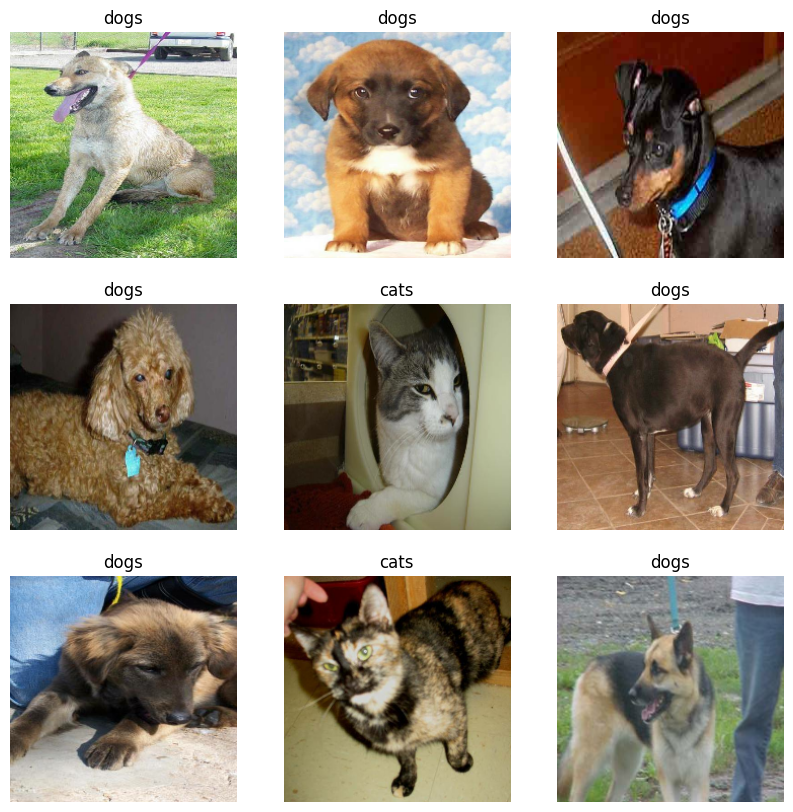

In [ ]:
# Visualizing just for testing
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[int(labels[i])])
    plt.axis('off')
plt.show()

# **Data Augmentation**

In [ ]:
# Augmentation pipeline
data_augmentation = tf.keras.Sequential(
    [ tf.keras.layers.RandomFlip('horizontal'),
      tf.keras.layers.RandomRotation(0.1),
      tf.keras.layers.RandomZoom(0.2),
      tf.keras.layers.RandomContrast(0.2) ]
    )

In [ ]:
# Applying augmentation
augmented_train_dataset = train_dataset.map( lambda x, y: (data_augmentation(x, training=True), y),
                                            num_parallel_calls=AUTOTUNE ).prefetch(AUTOTUNE)

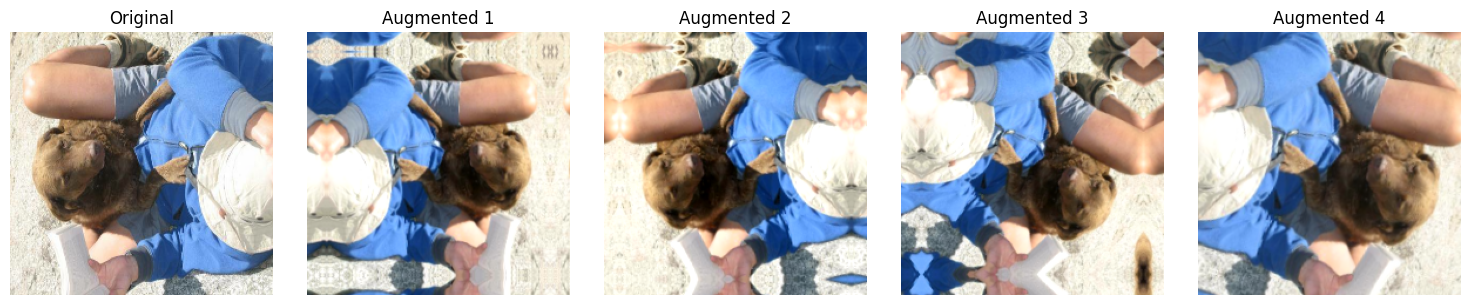

In [ ]:
# Augmented images
for images, labels in train_dataset.take(1):
  original_image = images[0]
  plt.figure(figsize=(15, 3))
  plt.subplot(1, 5, 1)
  plt.imshow(original_image)
  plt.title('Original')
  plt.axis('off')

  for i in range(4):
    augmented_image = data_augmentation( tf.expand_dims(original_image, 0), training=True )
    plt.subplot(1, 5, i + 2)
    plt.imshow(augmented_image[0])
    plt.title(f'Augmented {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

# **Custom CNN Model**

In [ ]:
# Building CNN architechture
custom_cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(), tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(), tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
    ])

custom_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456,385 (1.74 MB)

 Trainable params: 455,425 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# Compling the model
custom_cnn.compile( optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                   loss='binary_crossentropy', metrics=['accuracy'] )

In [ ]:
# Early-stopping the callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True )

In [ ]:
# Training the model using callback
history_custom = custom_cnn.fit(
    augmented_train_dataset,
    validation_data=validation_dataset,
    epochs=20, callbacks=[early_stopping] )

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 203s 381ms/step - accuracy: 0.6061 - loss: 0.6767 - val_accuracy: 0.5404 - val_loss: 0.7764
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 178s 354ms/step - accuracy: 0.6508 - loss: 0.6223 - val_accuracy: 0.6805 - val_loss: 0.6119
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 181s 361ms/step - accuracy: 0.6855 - loss: 0.5932 - val_accuracy: 0.7113 - val_loss: 0.5679
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 183s 363ms/step - accuracy: 0.7116 - loss: 0.5635 - val_accuracy: 0.6657 - val_loss: 0.5951
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 179s 357ms/step - accuracy: 0.7471 - loss: 0.5139 - val_accuracy: 0.6552 - val_loss: 0.6830
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 184s 366ms/step - accuracy: 0.7925 - loss: 0.4472 - val_accuracy: 0.6597 - val_loss: 0.7413


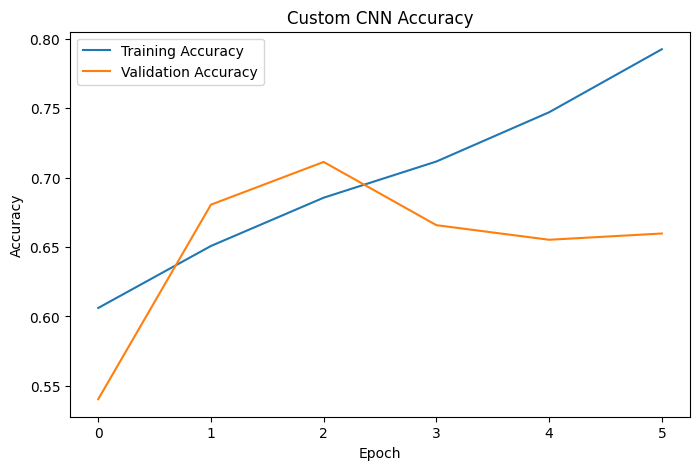

In [ ]:
# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_custom.history['accuracy'], label='Training Accuracy')
plt.plot(history_custom.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Custom CNN Accuracy')
plt.legend()
plt.show()

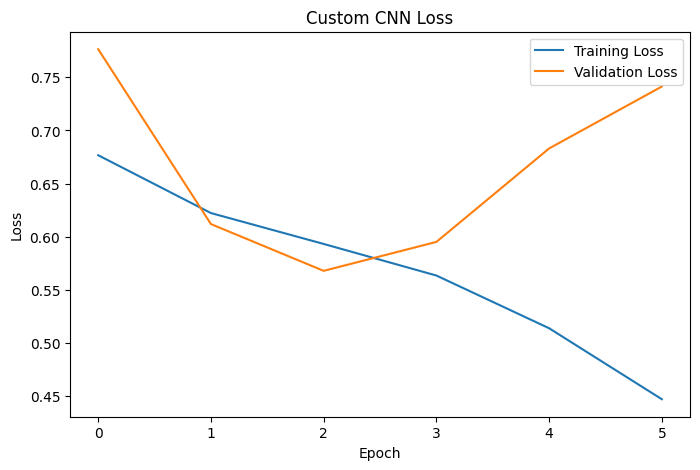

In [ ]:
# Training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_custom.history['loss'], label='Training Loss')
plt.plot(history_custom.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Custom CNN Loss')
plt.legend()
plt.show()

# **Transfer Learning / Feature Extraction**

In [ ]:
# Using MobileNetV2 as Pretrained backbone
base_model_fe = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet' )

In [ ]:
# Freeze backbone
base_model_fe.trainable = False

In [ ]:
# New Classification head
feature_extraction_model = tf.keras.Sequential([ tf.keras.layers.Input(shape=(224, 224, 3)),
                                                  tf.keras.layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input), base_model_fe,
                                                  tf.keras.layers.GlobalAveragePooling2D(),
                                                  tf.keras.layers.Dropout(0.3), tf.keras.layers.Dense(128, activation='relu'),
                                                  tf.keras.layers.Dropout(0.3), tf.keras.layers.Dense(1, activation='sigmoid') ])
feature_extraction_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Compiling model
feature_extraction_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'] )

In [ ]:
# Early-stopping the callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
    )

In [ ]:
# Training new classifier
history_fe = feature_extraction_model.fit(
    augmented_train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=[early_stopping] )

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 228s 416ms/step - accuracy: 0.5087 - loss: 0.7049 - val_accuracy: 0.5104 - val_loss: 0.6923
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 223s 368ms/step - accuracy: 0.5129 - loss: 0.6935 - val_accuracy: 0.4896 - val_loss: 0.6928
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 198s 361ms/step - accuracy: 0.5082 - loss: 0.6929 - val_accuracy: 0.5569 - val_loss: 0.6923
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 175s 348ms/step - accuracy: 0.5151 - loss: 0.6921 - val_accuracy: 0.5622 - val_loss: 0.6887
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 211s 367ms/step - accuracy: 0.5263 - loss: 0.6914 - val_accuracy: 0.5602 - val_loss: 0.6899
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 210s 418ms/step - accuracy: 0.5194 - loss: 0.6914 - val_accuracy: 0.5649 - val_loss: 0.6899
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 217s 433ms/step - accuracy: 0.5275 - loss: 0.6898 - val_accuracy: 0.5647 - val_loss: 0.6837
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 193s 382ms/step - accuracy: 0.5340 -

In [ ]:
# Evaluating feature extraction model
fe_test_loss, fe_test_accuracy = feature_extraction_model.evaluate(test_dataset)
print('Feature Extraction Test Accuracy:', fe_test_accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - accuracy: 0.5782 - loss: 0.6791
Feature Extraction Test Accuracy: 0.5781999826431274




**Why freezing the backbone is useful ?**

Ans:  


*   It reduces the number of trainable parameters.
*   Pretrained ImageNet features already capture useful visual    patterns such as edges, textures, and shapes.


*   Freezing prevents these learned features from being destroyed during training.
*   Training becomes faster and requires less computational power.








# Full Fine-Tuning

In [ ]:
# Using EfficientNetB0 as pretrained model
base_model_ft = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet' )

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Replacing Classifier
inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model_ft(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
fine_tuned_model = tf.keras.Model(inputs, outputs)

In [ ]:
# Unfreezing all layers
base_model_ft.trainable = True

In [ ]:
# Compiling model
fine_tuned_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy'] )

In [ ]:
# Early-stopping the callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True )

In [ ]:
# Fine-tuing the entire network
history_ft = fine_tuned_model.fit(
    augmented_train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=[early_stopping] )

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 386s 593ms/step - accuracy: 0.7579 - loss: 0.4927 - val_accuracy: 0.7776 - val_loss: 0.4357
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 188s 374ms/step - accuracy: 0.9282 - loss: 0.2072 - val_accuracy: 0.9224 - val_loss: 0.1839
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 188s 375ms/step - accuracy: 0.9487 - loss: 0.1354 - val_accuracy: 0.8909 - val_loss: 0.3116
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 197s 364ms/step - accuracy: 0.9592 - loss: 0.1055 - val_accuracy: 0.9772 - val_loss: 0.0651
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 203s 367ms/step - accuracy: 0.9680 - loss: 0.0881 - val_accuracy: 0.9732 - val_loss: 0.0756
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 202s 366ms/step - accuracy: 0.9672 - loss: 0.0845 - val_accuracy: 0.9550 - val_loss: 0.1141
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 183s 364ms/step - accuracy: 0.9725 - loss: 0.0703 - val_accuracy: 0.9812 - val_loss: 0.0492
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 181s 362ms/step - accuracy: 0.9771 -

**Explain the difference between feature extraction and full fine-tuning.**
---
Ans:

      Feature Extraction  ||  Full Fine Tuing
*   Backbone is frozen  ||
Backbone is trainable
*   Only new classifier is trained ||
Entire network is trained


*   Lower risk of overfitting ||
Higher risk of overfitting
*   Requires less GPU memory  ||
Requires more GPU memory





In [ ]:
# Evaluating this model for understanding
ft_test_loss, ft_test_accuracy = fine_tuned_model.evaluate(test_dataset)
print('Fine-Tuned Test Accuracy:', ft_test_accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - accuracy: 0.9864 - loss: 0.0348
Fine-Tuned Test Accuracy: 0.9864000082015991


# **Model Comparison**

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

In [ ]:
# A helper function
def evaluate_model(model, dataset):
  y_true = []
  y_pred = []
  for images, labels in dataset:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().astype(int).flatten())
    y_pred.extend((predictions > 0.5).astype(int).flatten())
  loss, accuracy = model.evaluate(dataset, verbose=0)
  precision = precision_score(y_true, y_pred)
  recall = recall_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred)
  return loss, accuracy, precision, recall, f1

In [ ]:
# Computing different metrices
custom_metrics = evaluate_model(custom_cnn, test_dataset)
fe_metrics = evaluate_model(feature_extraction_model, test_dataset)
ft_metrics = evaluate_model(fine_tuned_model, test_dataset)

In [ ]:
# Comparison Table
comparison_df = pd.DataFrame({
    'Model': [ 'Custom CNN', 'Feature Extraction', 'Fine-Tuned' ],
    'Total Parameters': [ custom_cnn.count_params(),
                         feature_extraction_model.count_params(),
                          fine_tuned_model.count_params() ],
    'Training Loss': [ history_custom.history['loss'][-1],
                      history_fe.history['loss'][-1],
                       history_ft.history['loss'][-1] ],
    'Training Accuracy': [ history_custom.history['accuracy'][-1],
                          history_fe.history['accuracy'][-1],
                          history_ft.history['accuracy'][-1] ],
    'Validation Loss': [ history_custom.history['val_loss'][-1],
                        history_fe.history['val_loss'][-1],
                         history_ft.history['val_loss'][-1] ],
    'Validation Accuracy': [ history_custom.history['val_accuracy'][-1],
                            history_fe.history['val_accuracy'][-1],
                             history_ft.history['val_accuracy'][-1] ],
    'Test Loss': [ custom_metrics[0],
                  fe_metrics[0],
                   ft_metrics[0] ],
    'Test Accuracy': [ custom_metrics[1],
                      fe_metrics[1],
                       ft_metrics[1] ],
    'Test Precision': [ custom_metrics[2],
                       fe_metrics[2],
                        ft_metrics[2] ],
    'Test Recall': [ custom_metrics[3],
                    fe_metrics[3],
                     ft_metrics[3] ],
    'Test F1 Score': [ custom_metrics[4],
                      fe_metrics[4],
                       ft_metrics[4] ]
    })
comparison_df

,Model,Total Parameters,Training Loss,Training Accuracy,Validation Loss,Validation Accuracy,Test Loss,Test Accuracy,Test Precision,Test Recall,Test F1 Score
0,Custom CNN,456385,0.447200,0.792459,0.741274,0.659745,0.562315,0.7184,0.717011,0.7216,0.719298
1,Feature Extraction,2422081,0.685218,0.551276,0.679830,0.574931,0.679081,0.5782,0.613333,0.4232,0.500828
2,Fine-Tuned,4213668,0.058220,0.977676,0.037394,0.986240,0.034778,0.9864,0.986400,0.9864,0.986400


***1. Which model performed best?***
---
**Ans:** The Fine-Tuned EfficientNetB0 model is expected to achieve the highest validation and test accuracy because all pretrained layers are allowed to adapt to the Dog vs Cat dataset.
---
***2. Which model is most computationally efficient?***
---
**Ans:** The Feature Extraction (MobileNetV2) model is the most computationally efficient because the pretrained backbone is frozen and only a small classification head is trained.
---
***3. Which model would you deploy in production, and why ?***
---
**Ans:** For production deployment, MobileNetV2 Feature Extraction is often the best trade-off between accuracy, inference speed, memory usage, and deployment cost, especially for web or mobile applications.
---


# **Error Analysis**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
# Reusable function
def error_analysis(model, test_dataset, class_names):
  y_true = []
  y_pred = []
  confidences = []
  misclassified_images = []
  for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0).flatten()
    predicted_labels = (predictions > 0.5).astype(int)
    y_true.extend(labels.numpy().astype(int).flatten())
    y_pred.extend(predicted_labels)
    confidences.extend(predictions)

    for i in range(len(labels)):
      if predicted_labels[i] != int(labels[i]):
        misclassified_images.append(( images[i].numpy(), int(labels[i]), predicted_labels[i], predictions[i] ))
    print('Classification Report')
    print(classification_report( y_true, y_pred, target_names=class_names ))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap( cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names )

    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    plt.figure(figsize=(12, 12))
    for i, (image, actual, predicted, confidence) in enumerate(misclassified_images[:9]):
      plt.subplot(3, 3, i + 1)
      plt.imshow(image)
      plt.title( f'Actual: {class_names[actual]}\\n' f'Pred: {class_names[predicted]}\\n' f'Conf: {confidence:.2f}' )
      plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Running error analysis
error_analysis( fine_tuned_model, test_dataset, class_names )